<a href="https://colab.research.google.com/github/BhumikaSasmal/Algorithms/blob/main/MergeSortAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Merge Sort

**Merge Sort** is a divide-and-conquer sorting algorithm that repeatedly divides an array into smaller subarrays, sorts them, and then merges them back together in sorted order.

## How It Works

1. **Divide:** Split the array into two halves.
2. **Repeat:** Continue dividing each half until every subarray contains only one element.
3. **Merge:** Compare elements from the smaller sorted subarrays and merge them in the correct order.
4. **Combine:** Continue merging the sorted subarrays until the entire array is sorted.

## Summary

* **Approach:** Divide and Conquer.
* **Time Complexity:** O(n log n).
* **Space Complexity:** O(n).
* **Key Point:** The array is divided into smaller parts and then merged back together in sorted order.


In [11]:
import random
import matplotlib.pyplot as plt


def merge_sort(arr):
    comparisons = 0
    if len(arr) <= 1:
        return arr, comparisons
    mid = len(arr) // 2
    left, left_comparisons = merge_sort(arr[:mid])
    right, right_comparisons = merge_sort(arr[mid:])
    comparisons += left_comparisons
    comparisons += right_comparisons
    merged = []
    i = 0
    j = 0
    while i < len(left) and j < len(right):
        comparisons += 1
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    merged.extend(left[i:])
    merged.extend(right[j:])

    return merged, comparisons




# Best, Average and Worst Case for Merge Sort

* **Best Case Scenario:** When the array requires the minimum number of comparisons during the merging process.
* **Average Case Scenario:** When the elements are arranged in a random order.
* **Worst Case Scenario:** When the array requires the maximum number of comparisons during merging.
* **Time Complexity:** O(n log n) for **Best, Average and Worst Case**.

- **Consistent Division:** The array is always divided into smaller halves regardless of its initial order.
- **Repeated Merging:** The subarrays are merged back together at every level.
- **Logarithmic Levels:** The array is divided approximately **log n** times.
- **Linear Work:** Each level processes approximately **n elements** during merging.
- **Consistent Performance:** The divide-and-merge process results in O(n log n) time across all cases.



In [12]:


def create_array(n):
    return random.sample(range(1, n * 10 + 1), n)

def create_merge_worst_array(values):
    if len(values) <= 1:
        return values

    left = values[::2]
    right = values[1::2]

    left = create_merge_worst_array(left)
    right = create_merge_worst_array(right)

    return left + right


sizes = [2, 4, 8, 16, 32, 64, 128]

trials = 100

random.seed(42)

merge_best = []
merge_average = []
merge_worst = []


for n in sizes:

    arr = list(range(n))
    _, comparisons = merge_sort(arr)
    merge_best.append(comparisons)

    total = 0

    for _ in range(trials):
        arr = create_array(n)
        _, comparisons = merge_sort(arr)
        total += comparisons

    merge_average.append(total / trials)

    arr = create_merge_worst_array(list(range(n)))
    _, comparisons = merge_sort(arr)
    merge_worst.append(comparisons)


print("MERGE SORT")
print("=" * 55)
print("Size\tBest\tAverage\tWorst")

for i in range(len(sizes)):
    print(
        sizes[i],
        "\t",
        round(merge_best[i], 2),
        "\t",
        round(merge_average[i], 2),
        "\t",
        round(merge_worst[i], 2)
    )


MERGE SORT
Size	Best	Average	Worst
2 	 1 	 1.0 	 1
4 	 4 	 4.65 	 5
8 	 12 	 15.78 	 17
16 	 32 	 45.71 	 49
32 	 80 	 121.16 	 129
64 	 192 	 305.18 	 321
128 	 448 	 736.27 	 769


# Plotting Graphs

With our code for Merge Sort done and the data for best, average and worst case for various array sizes collected, we can now plot them into graphs for observation.


# MERGE SORT - BEST CASE

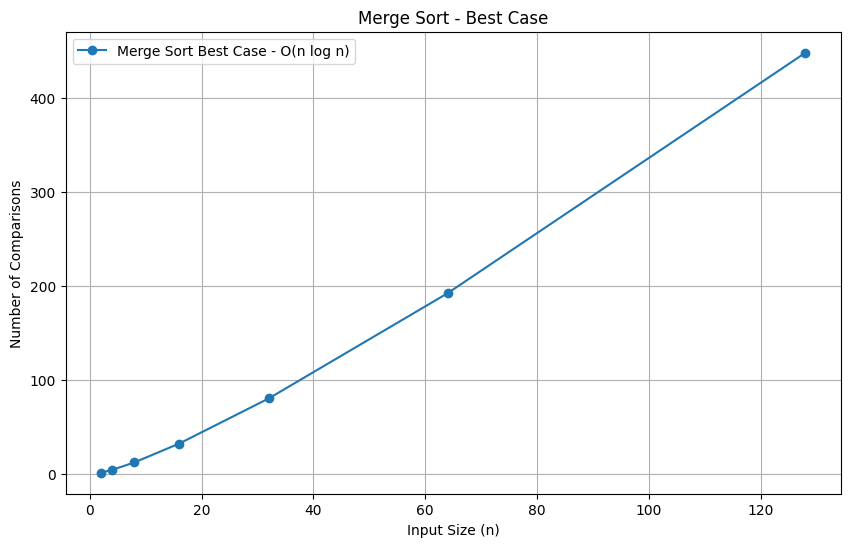

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    merge_best,
    marker='o',
    label='Merge Sort Best Case - O(n log n)'
)

plt.xlabel("Input Size (n)")
plt.ylabel("Number of Comparisons")
plt.title("Merge Sort - Best Case")

plt.legend()
plt.grid(True)

plt.show()



# MERGE SORT - AVERAGE CASE

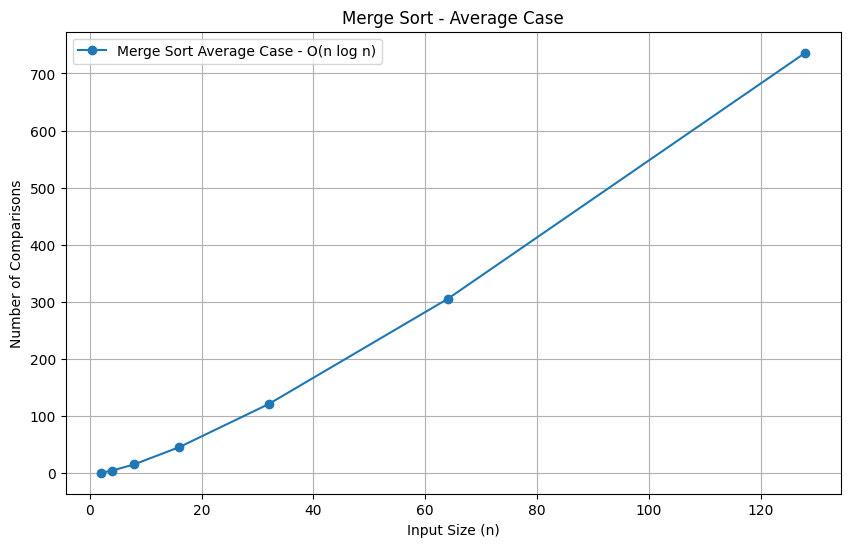

In [14]:

plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    merge_average,
    marker='o',
    label='Merge Sort Average Case - O(n log n)'
)

plt.xlabel("Input Size (n)")
plt.ylabel("Number of Comparisons")
plt.title("Merge Sort - Average Case")

plt.legend()
plt.grid(True)

plt.show()





# MERGE SORT - WORST CASE

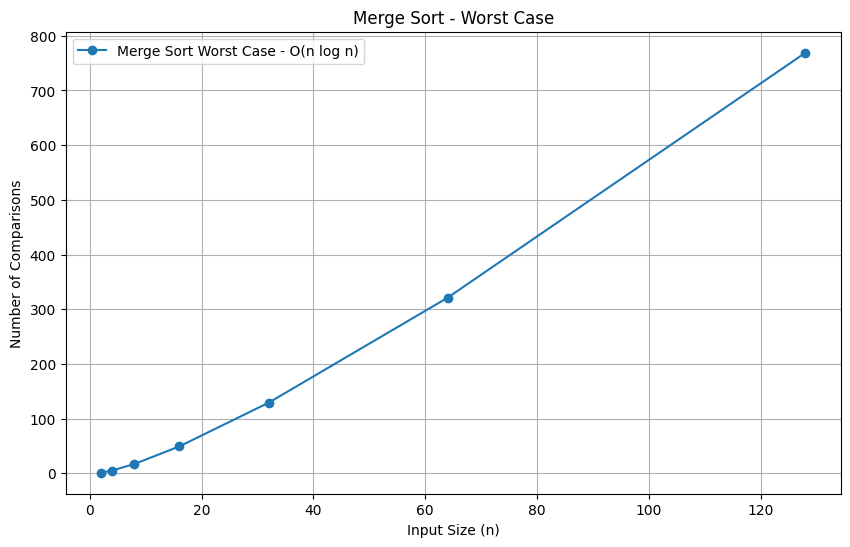

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    merge_worst,
    marker='o',
    label='Merge Sort Worst Case - O(n log n)'
)

plt.xlabel("Input Size (n)")
plt.ylabel("Number of Comparisons")
plt.title("Merge Sort - Worst Case")

plt.legend()
plt.grid(True)

plt.show()


# Merge Sort - Best, Average, and Worst Cases

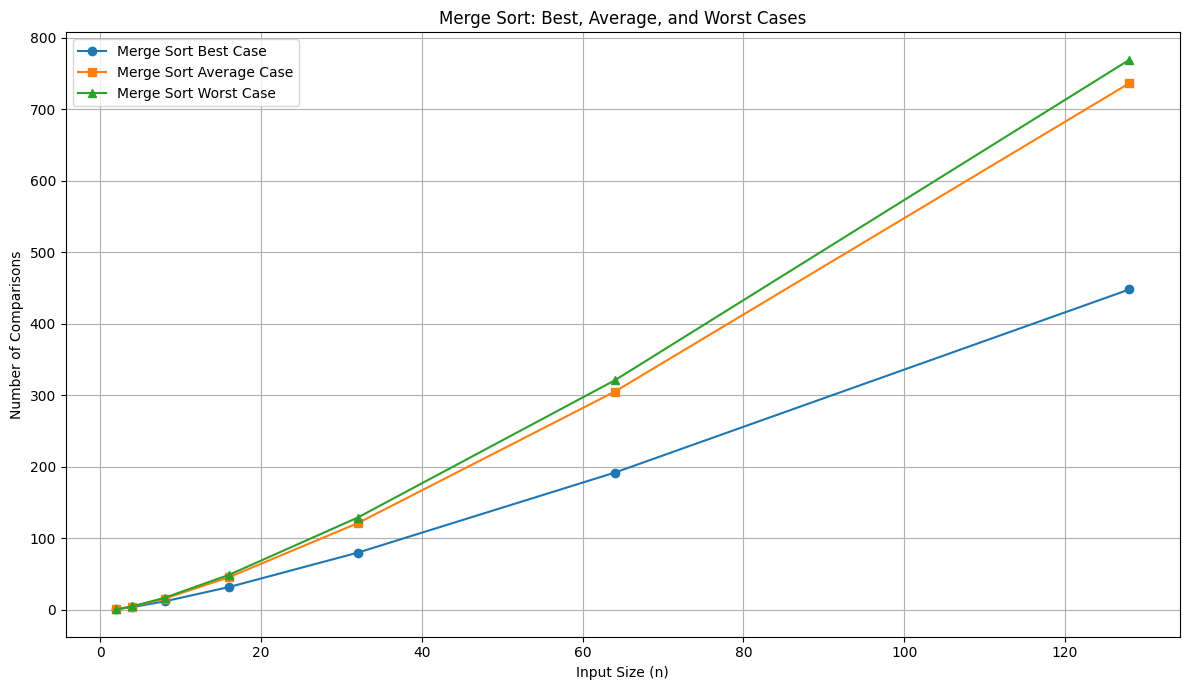

In [16]:
plt.figure(figsize=(12, 7))

plt.plot(
    sizes,
    merge_best,
    marker="o",
    label="Merge Sort Best Case"
)

plt.plot(
    sizes,
    merge_average,
    marker="s",
    label="Merge Sort Average Case"
)

plt.plot(
    sizes,
    merge_worst,
    marker="^",
    label="Merge Sort Worst Case"
)

plt.title("Merge Sort: Best, Average, and Worst Cases")
plt.xlabel("Input Size (n)")
plt.ylabel("Number of Comparisons")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



# Conclusion

* **Best Case:** O(n log n)
* **Average Case:** O(n log n)
* **Worst Case:** O(n log n)

Merge Sort provides **consistent and predictable performance** regardless of the initial arrangement of the array.

Unlike Bubble Sort and Selection Sort, which can require O(n²) time, Merge Sort maintains **O(n log n)** time even in the worst case.

**Overall:** Merge Sort is an efficient choice for sorting **large datasets**, but it requires additional **O(n) space** for the merging process.
